# CMEMS SST products — per-sensor L3, multi-sensor L3S, and L4 OSTIA

A walk through the [Copernicus Marine sea-surface-temperature family](https://data.marine.copernicus.eu/products): three single-sensor L3 streams (geostationary IR, polar IR, passive μW), the **ODYSSEA L3S** multi-sensor merge, and the operational **OSTIA L4** gap-free analysis. Same Gulf Stream window as the SSH notebook so the front structure lines up.

> **Region & window**: Gulf Stream `[-70°, -50°] × [30°, 45°]`, **2026-01-01 → 2026-01-15** (same as the SSH notebook for cross-family consistency).

Credentials live in the project-root `.env` (`COPERNICUSMARINE_SERVICE_USERNAME` / `..._PASSWORD`).

## 1. Setup

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dotenv import load_dotenv

import copernicusmarine as cm

from xr_toolz.interpolate import Grid

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
load_dotenv()

/home/azureuser/localfiles/xr_toolz/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
BBOX = dict(
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
)
TIME = dict(start_datetime='2026-01-01', end_datetime='2026-01-15')

# Common 0.25° reference grid for cross-product comparison.
GRID = Grid.from_bounds(
    lon_bnds=(BBOX['minimum_longitude'], BBOX['maximum_longitude']),
    lat_bnds=(BBOX['minimum_latitude'],  BBOX['maximum_latitude']),
    resolution=0.25,
)
ref = xr.Dataset(coords={'longitude': GRID.lon, 'latitude': GRID.lat})
GRID.lon.shape, GRID.lat.shape

((81,), (61,))

In [3]:
def to_common_grid(da: xr.DataArray, *, ref: xr.Dataset = ref) -> xr.DataArray:
    """Interpolate a 2D DataArray (with lat/lon coords) onto the 0.25° reference grid.

    Source resolutions in this family vary (0.05°, 0.1°, 0.25°, 4 km, 300 m); we put
    everything on a single 0.25° grid so cross-product panels share a coordinate system.
    """
    return da.interp(
        latitude=ref['latitude'],
        longitude=ref['longitude'],
        method='linear',
    )

## 2. Per-sensor L3 — see the cloud / swath gaps

Each L3 stream is the daily merge of one sensor family. They are gridded but **not gap-filled**: cloudy / unilluminated pixels stay NaN.

- `gir` — geostationary IR (e.g. SEVIRI, GOES). High revisit, fine 0.05° grid, *loses everything covered by cloud*.
- `pir` — polar-orbiting IR (AVHRR / SLSTR). 0.1°. Cleaner SST when clear.
- `pmw` — passive microwave (AMSR2). Coarse 0.25°, **sees through non-precipitating cloud**.

In [4]:
L3_PER_SENSOR = {
    'gir (geo IR)':   'cmems_obs-sst_glo_phy_l3s_gir_P1D-m',
    'pir (polar IR)': 'cmems_obs-sst_glo_phy_l3s_pir_P1D-m',
    'pmw (passive μW)': 'cmems_obs-sst_glo_phy_l3s_pmw_P1D-m',
}
ds_l3 = {
    label: cm.open_dataset(dataset_id=did, **BBOX, **TIME)
    for label, did in L3_PER_SENSOR.items()
}
{lbl: dict(ds.sizes) for lbl, ds in ds_l3.items()}

INFO - 2026-04-28T10:50:45Z - Selected dataset version: "202311"


INFO - 2026-04-28T10:50:45Z - Selected dataset part: "default"


INFO - 2026-04-28T10:50:49Z - Selected dataset version: "202311"


INFO - 2026-04-28T10:50:49Z - Selected dataset part: "default"


INFO - 2026-04-28T10:50:53Z - Selected dataset version: "202311"


INFO - 2026-04-28T10:50:53Z - Selected dataset part: "default"


{'gir (geo IR)': {'time': 15, 'latitude': 300, 'longitude': 400},
 'pir (polar IR)': {'time': 15, 'latitude': 150, 'longitude': 200},
 'pmw (passive μW)': {'time': 15, 'latitude': 60, 'longitude': 80}}

### One day, three sensors

Pick a single mid-window day so you see each sensor's coverage for that day.

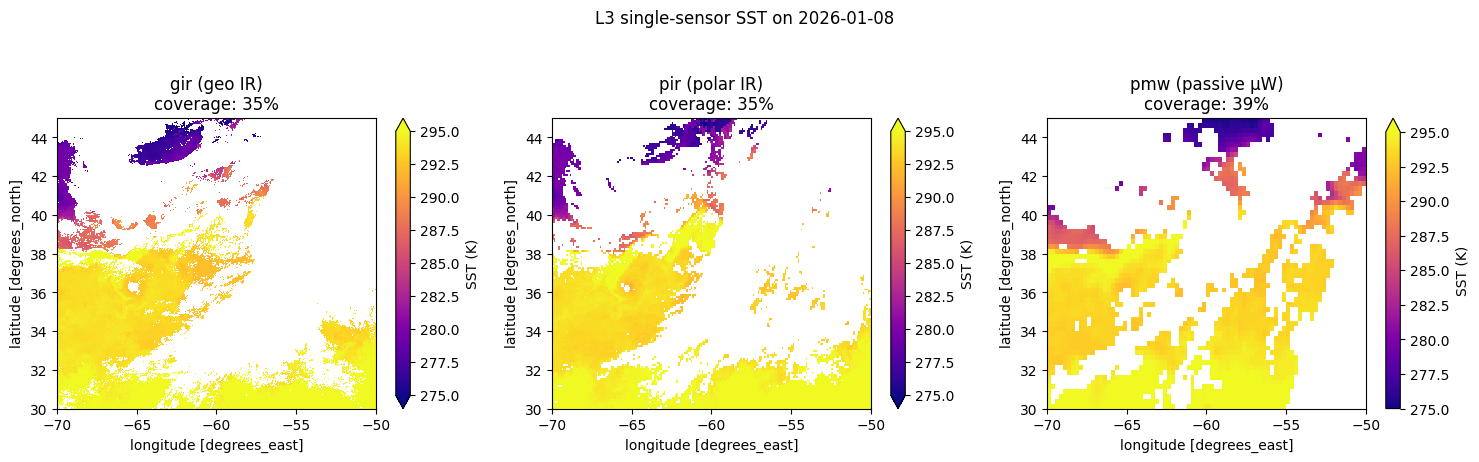

In [5]:
DAY = '2026-01-08'
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
vmin, vmax = 275, 295  # K
for ax, (label, ds) in zip(axes, ds_l3.items(), strict=False):
    sst = ds['sea_surface_temperature'].sel(time=DAY, method='nearest').squeeze()
    sst.plot.pcolormesh(ax=ax, cmap='thermal' if 'thermal' in plt.colormaps() else 'plasma',
                        vmin=vmin, vmax=vmax,
                        cbar_kwargs={'label': 'SST (K)'})
    cov = float(np.isfinite(sst).mean())
    ax.set_title(f'{label}\ncoverage: {cov:.0%}')
fig.suptitle(f'L3 single-sensor SST on {DAY}', y=1.04)
plt.tight_layout()
plt.show()

### 15-day coverage map per sensor

Fraction of valid SST values at each pixel across the window — i.e. how many of the 15 daily fields had a non-NaN value there. PMW pays for its cloud tolerance with a much coarser grid.

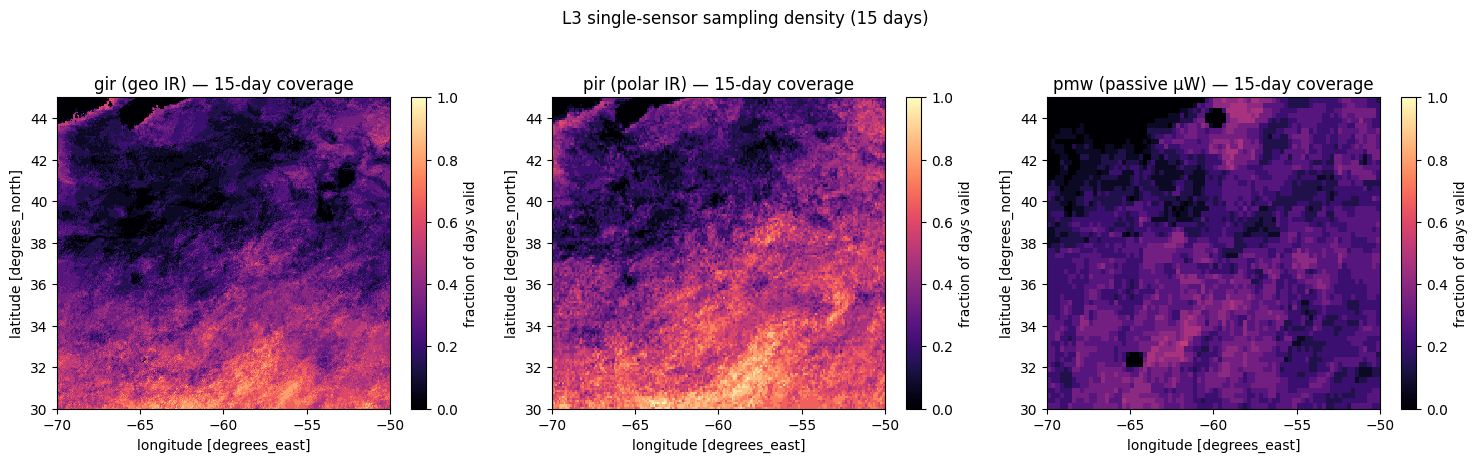

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (label, ds) in zip(axes, ds_l3.items(), strict=False):
    valid = np.isfinite(ds['sea_surface_temperature']).mean('time')
    valid.plot.pcolormesh(ax=ax, cmap='magma', vmin=0, vmax=1,
                          cbar_kwargs={'label': 'fraction of days valid'})
    ax.set_title(f'{label} — 15-day coverage')
fig.suptitle('L3 single-sensor sampling density (15 days)', y=1.04)
plt.tight_layout()
plt.show()

## 3. Multi-sensor L3S — ODYSSEA

ODYSSEA L3S merges the IR sensors (and in some configurations PMW) into a single L3 product. Still daily, still has gaps where every sensor was cloudy on that day.

In [7]:
ds_l3s = cm.open_dataset(
    dataset_id='cmems_obs-sst_glo_phy_my_l3s_P1D-m',
    **BBOX, **TIME,
)
list(ds_l3s.data_vars), dict(ds_l3s.sizes)

INFO - 2026-04-28T10:51:08Z - Selected dataset version: "202311"


INFO - 2026-04-28T10:51:08Z - Selected dataset part: "default"


WARNING - 2026-04-28T10:51:08Z - Some of your subset selection [2026-01-01 00:00:00+00:00, 2026-01-15 00:00:00+00:00] for the time dimension exceed the dataset coordinates [1982-01-01 00:00:00+00:00, 2026-01-05 00:00:00+00:00]


([np.str_('adjusted_sea_surface_temperature'),
  np.str_('bias_to_reference_sst'),
  np.str_('quality_level'),
  np.str_('sea_surface_temperature'),
  np.str_('sources_of_sst'),
  np.str_('sses_bias'),
  np.str_('sses_standard_deviation'),
  np.str_('sst_dtime')],
 {'time': 5, 'latitude': 150, 'longitude': 200})

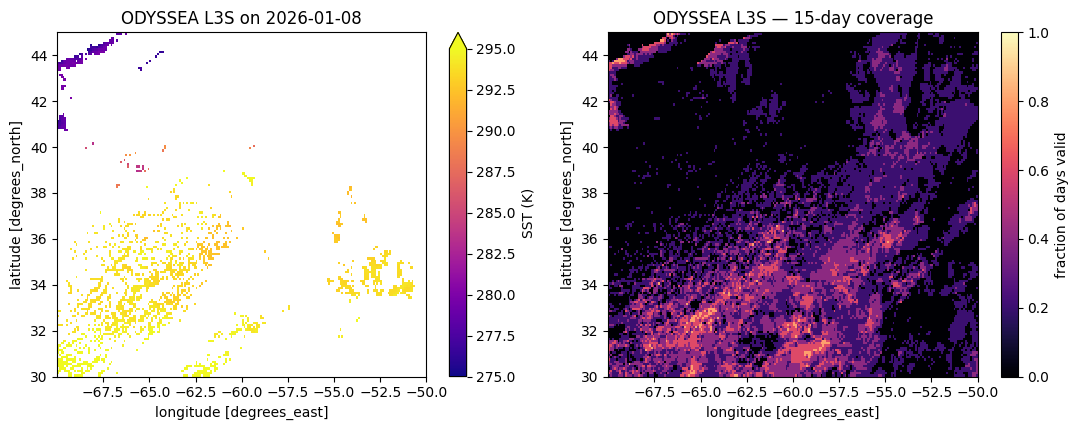

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ds_l3s['sea_surface_temperature'].sel(time=DAY, method='nearest').squeeze().plot.pcolormesh(
    ax=axes[0], cmap='plasma', vmin=vmin, vmax=vmax,
    cbar_kwargs={'label': 'SST (K)'},
)
axes[0].set_title(f'ODYSSEA L3S on {DAY}')
valid_l3s = np.isfinite(ds_l3s['sea_surface_temperature']).mean('time')
valid_l3s.plot.pcolormesh(ax=axes[1], cmap='magma', vmin=0, vmax=1,
                          cbar_kwargs={'label': 'fraction of days valid'})
axes[1].set_title('ODYSSEA L3S — 15-day coverage')
plt.tight_layout()
plt.show()

## 4. L4 — OSTIA gap-free analysis (NRT)

OSTIA L4 ingests every L3 stream, applies optimal-interpolation analysis with a sea-ice mask, and emits a **fully gap-free** SST + sea-ice field every day at 0.05°. Reprocessed (REP) doesn't reach 2026 yet, so this notebook uses the operational NRT-V2 product.

In [9]:
ds_ostia = cm.open_dataset(
    dataset_id='METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2',
    **BBOX, **TIME,
)
list(ds_ostia.data_vars), dict(ds_ostia.sizes)

INFO - 2026-04-28T10:51:14Z - Selected dataset version: "default"


INFO - 2026-04-28T10:51:14Z - Selected dataset part: "default"


([np.str_('analysed_sst'),
  np.str_('analysis_error'),
  np.str_('mask'),
  np.str_('sea_ice_fraction')],
 {'time': 15, 'latitude': 300, 'longitude': 400})

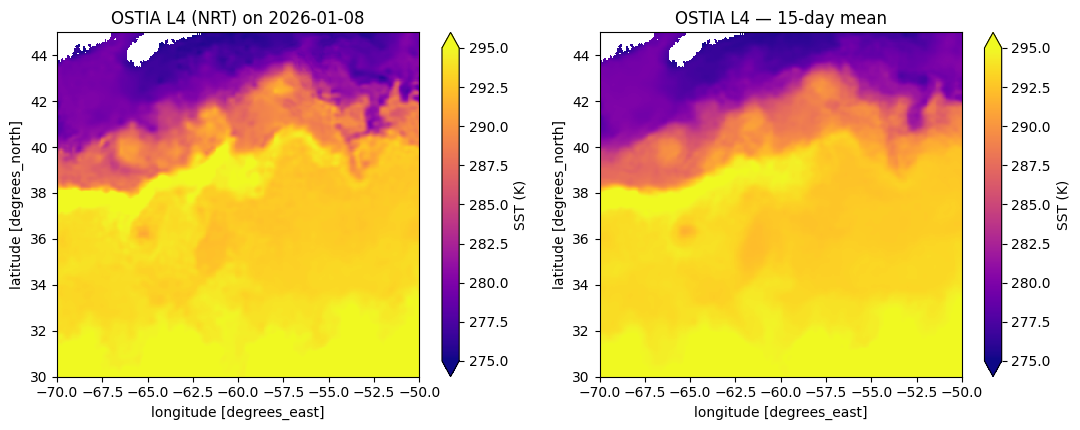

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ds_ostia['analysed_sst'].sel(time=DAY, method='nearest').squeeze().plot.pcolormesh(
    ax=axes[0], cmap='plasma', vmin=vmin, vmax=vmax,
    cbar_kwargs={'label': 'SST (K)'},
)
axes[0].set_title(f'OSTIA L4 (NRT) on {DAY}')
ds_ostia['analysed_sst'].mean('time').plot.pcolormesh(
    ax=axes[1], cmap='plasma', vmin=vmin, vmax=vmax,
    cbar_kwargs={'label': 'SST (K)'},
)
axes[1].set_title('OSTIA L4 — 15-day mean')
plt.tight_layout()
plt.show()

## 5. Cross-product comparison at 0.25°

Each product on a different native resolution. Regrid all of them onto the **common 0.25° reference grid** with `to_common_grid()` so the panels line up cell-for-cell. We use the 15-day mean as the comparison metric.

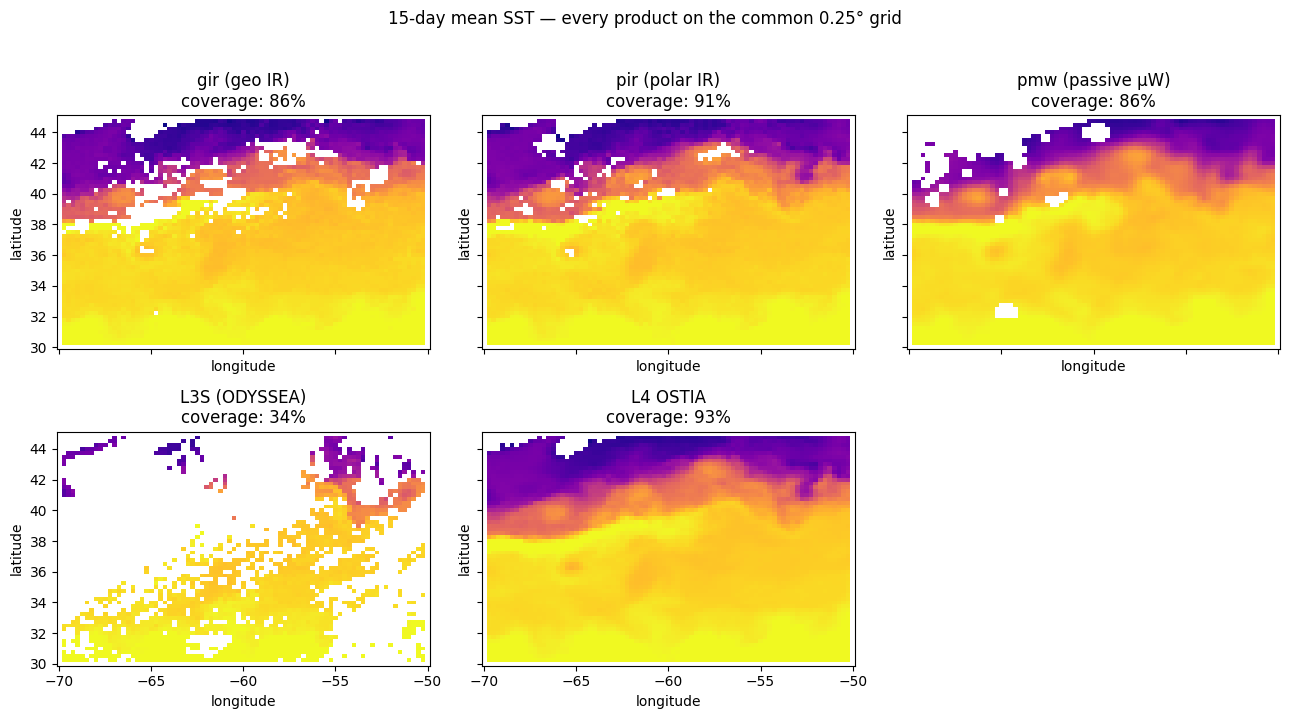

In [11]:
products_25 = {
    label: to_common_grid(ds['sea_surface_temperature'].mean('time'))
    for label, ds in ds_l3.items()
}
products_25['L3S (ODYSSEA)'] = to_common_grid(ds_l3s['sea_surface_temperature'].mean('time'))
products_25['L4 OSTIA'] = to_common_grid(ds_ostia['analysed_sst'].mean('time'))

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, (label, da) in zip(axes.ravel(), products_25.items(), strict=False):
    da.plot.pcolormesh(ax=ax, cmap='plasma', vmin=vmin, vmax=vmax,
                       add_colorbar=False)
    cov = float(np.isfinite(da).mean())
    ax.set_title(f'{label}\ncoverage: {cov:.0%}')
axes.ravel()[-1].axis('off')
fig.suptitle('15-day mean SST — every product on the common 0.25° grid', y=1.02)
plt.tight_layout()
plt.show()

### L3S − L4 difference

Where the multi-sensor L3 has data, how does it compare to the OI-mapped L4?

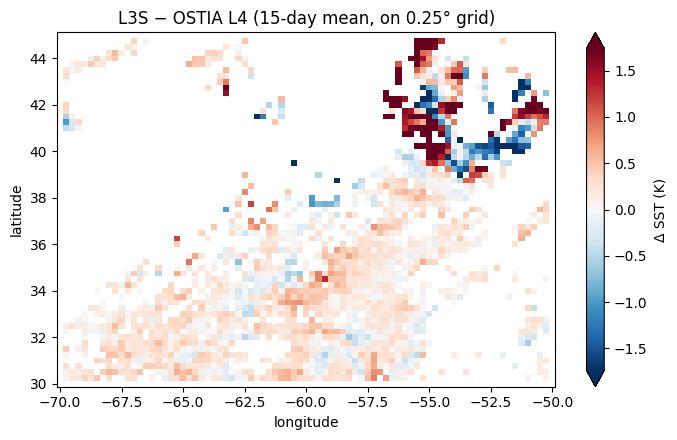

In [12]:
diff = products_25['L3S (ODYSSEA)'] - products_25['L4 OSTIA']
fig, ax = plt.subplots(figsize=(7, 4.5))
dvmax = float(np.nanpercentile(np.abs(diff.values), 95))
diff.plot.pcolormesh(ax=ax, cmap='RdBu_r', vmin=-dvmax, vmax=dvmax,
                     cbar_kwargs={'label': 'Δ SST (K)'})
ax.set_title('L3S − OSTIA L4 (15-day mean, on 0.25° grid)')
plt.tight_layout()
plt.show()

## Takeaways

- **L3 single-sensor** is the rawest gridded view: maximum spatial detail where sampled, but every individual stream loses huge fractions of pixels to cloud or revisit gaps.
- **L3S multi-sensor** trades a small loss in nominal resolution for a much smaller hole pattern — *but it still has gaps*.
- **L4 OSTIA** is the gap-free product the rest of the system depends on, at the cost of having been mapped through OI: the small-scale structure you see in L3 IR is largely smoothed out.
- Putting everything on the same 0.25° grid via `to_common_grid()` is the minimum scaffolding for cross-product comparison; a fairer evaluation would coarsen each product **before** the resolution-matching interp.